## Cópula de Plackett

Algoritmo para generar variables aleatorias $(u,v)$ de una distribución de Plackett con parámetro $\theta$:
1. Gererar dos variables independientes $(u,t)$ uniformes $(0,1)$.
2. Sea $a=t(1-t)$ \
$b=\theta+a(\theta-1)^2$ \
$c=2a(u\theta^2+1-u)+\theta(1-2a)$ \
$d=\sqrt(\theta)*\sqrt((\theta+4au(1-u)(1-\theta^2)))$

3. Sea $v=\frac{c-(1-2t)d}{2b}$

4. Asignar pares $(u,v)$

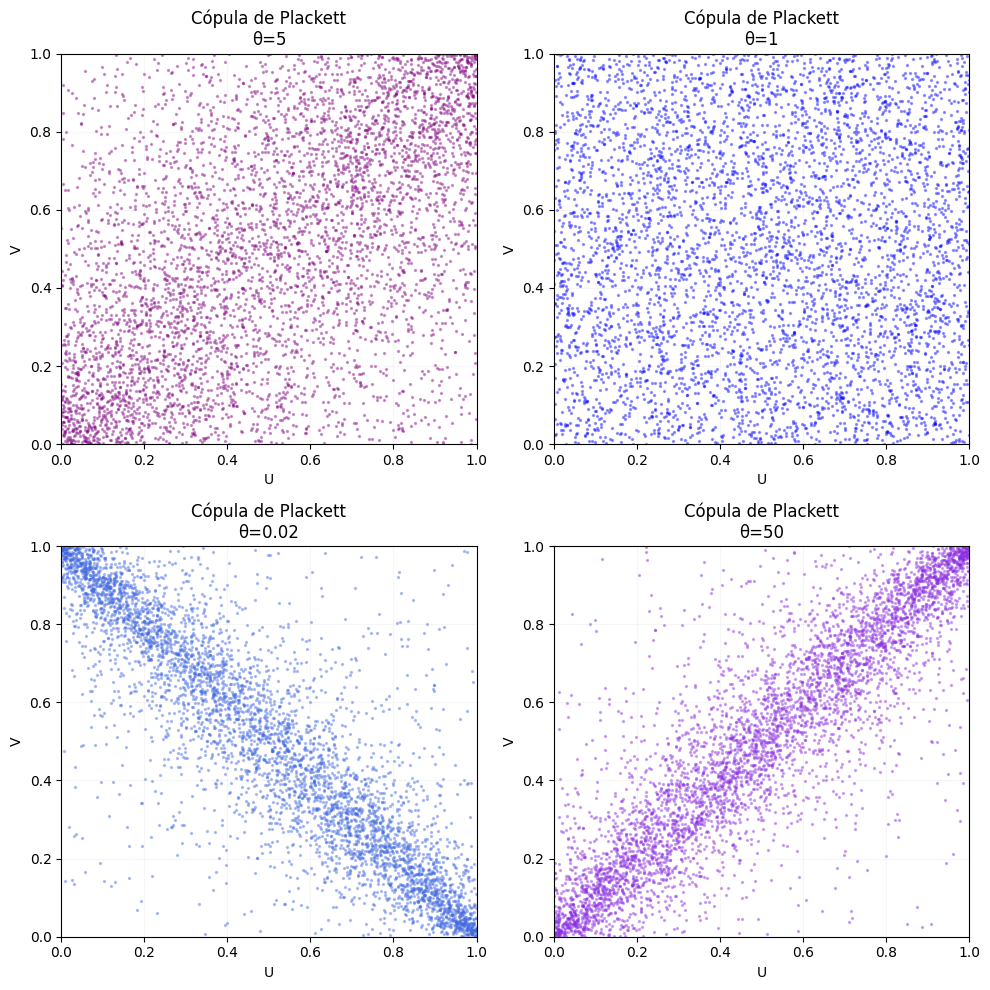

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def copula_plackett(n, theta):
    ###Generamos las variables aleatorias
    u = np.random.uniform(0, 1, n)
    t = np.random.uniform(0, 1, n)


    a= t*(1-t)
    b= theta+a*(theta-1)**2
    c= 2*a*(u*theta**2+1-u)+theta*(1-2*a)
    d= np.sqrt(theta)*np.sqrt((theta+4*a*u*(1-u)*(1-theta)**2))
    v= (c-(1-2*t)*d)/(2*b)

    return u, v


casos = [5,1,0.02,50] #Casos donde (ejemplo dado en el libro)
colores = ['purple','blue','royalblue','blueviolet']
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, theta, color in zip(axes.ravel(), casos, colores):
    u, v = copula_plackett(5000, theta)
    ax.scatter(u, v, alpha=0.35, s=2, color=color)
    ax.set_title(f'Cópula de Plackett\nθ={theta}', fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('U')
    ax.set_ylabel('V')
    ax.grid(True, alpha=0.1)
plt.tight_layout()
plt.show()

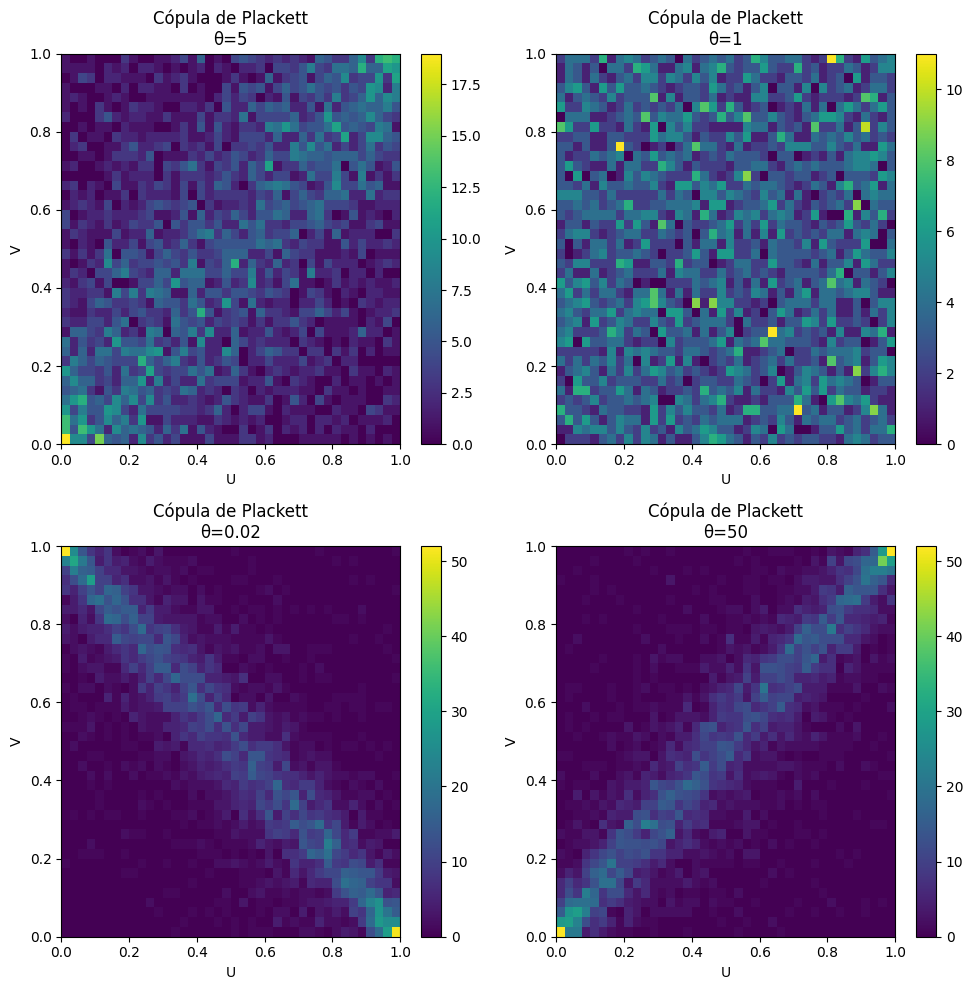

In [ ]:
### Mapas de calor
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, theta in zip(axes.ravel(), casos):
    u, v = copula_plackett(5000, theta)
    hb = ax.hist2d(u, v, bins=40, range=[[0, 1], [0, 1]], cmap="viridis")
    ax.set_title(f'Cópula de Plackett\nθ={theta}', fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('U')
    ax.set_ylabel('V')
    plt.colorbar(hb[3], ax=ax)

plt.tight_layout()
plt.show()

ejercicio 3.38